# Setting

## Library

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Matplotlib global settings
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 20
plt.rcParams['savefig.dpi'] = 500
plt.rc('font', family='serif')

In [3]:
# ML libraries
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

In [4]:
# Helper functions & model import
sys.path.append(os.path.join('..', 'src'))
from helper import makeSpecColors
from paths import *
from var import *
from sdtpy import *
from model import *

## Function

In [5]:
def select_uids_by_class(df, sample_number, class_col='Class', uid_col='uid', random_state=42):
    np.random.seed(random_state)
    uids_by_class = {}
    for c in df[class_col].unique():
        uids = df[df[class_col]==c][uid_col].unique()
        n_select = min(sample_number, len(uids))
        selected_uids = np.random.choice(uids, n_select, replace=False)
        uids_by_class[c] = set(selected_uids)
    return uids_by_class

In [6]:
def filter_by_selected_uids(df, uids_by_class, class_col='Class', uid_col='uid'):
    mask = np.zeros(len(df), dtype=bool)
    for c, uids in uids_by_class.items():
        mask |= ((df[class_col]==c) & (df[uid_col].isin(uids)))
    return df[mask]

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def train_test_split_by_uid(df, test_size=0.2, class_col='Class', uid_col='uid', random_state=42):
    groups = df[uid_col]
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(gss.split(df, df[class_col], groups))
    return df.iloc[train_idx], df.iloc[test_idx]

## Initial Setup

In [8]:
logtxt = ""

In [9]:
# Set experiment configs
test_name = "Tune_XGBoost_40_asteroid_only"
random_state = 42
test_size = 0.2
device_type = "gpu" # or cpu
n_jobs = -1
path_save = os.path.join(MODEL, test_name)
os.makedirs(path_save, exist_ok=True)

logtxt += "\nSet experiment configs\n"
logtxt += f"test_name: {test_name}\n"
logtxt += f"random_state: {random_state}\n"
logtxt += f"test_size: {test_size}\n"
logtxt += f"device_type: {device_type}\n"
logtxt += f"n_jobs: {n_jobs}\n"
logtxt += f"path_save: {path_save}\n"
logtxt += "\n"


- Source to Consider

In [10]:
sources_to_consider = [
	"AGN", 
	"Ia", 
	"II", 
	"Ibc", 
	# "LBV", 
	"TDE", 
	# "Nova", 
	# "M dwarf", 
	# "CV",
	"SLSN",
    "SV",
    "Asteroid",
]
logtxt += f"\nSources to consider: {sources_to_consider}\n"

In [11]:
path_data = os.path.join(FEATURE_NEW_DATA, 'features_40_color_only.csv')

logtxt += f"\nBalanced Data Set\n"

# Data

In [12]:
columns_to_use = list(data_dtype_dict.keys())

In [13]:
data = pd.read_csv(
    path_data,
    engine='c', 
    # usecols=columns_to_use,
    # dtype=data_dtype_dict,
)

data['uid'] = data['uid'].astype(str)
data['Class'] = data['Class'].astype(str)
data = data[data['Class'] == 'Asteroid']

#
class_mapping = {
    'Cb': 'C', 'Cg': 'C', 'Cgh': 'C', 'Ch': 'C',
    'Sa': 'S', 'Sq': 'S', 'Sr': 'S', 'Sv': 'S',
    'Xc': 'X', 'Xe': 'X', 'Xk': 'X', 'Xn': 'X'
}

def map_to_main_class(cls):
    return class_mapping.get(cls, cls)  # 기본은 자기 자신
#

uids = data['uid'].values
classes = data['Class'].values

print(f"Balanced Data: {len(data)}")

logtxt += f"Balanced Data: {len(data)}\n"

indx_type_to_consider = np.where(
	np.array([(data['Class'] == source) for source in sources_to_consider]).any(axis=0)
)

print(f"{len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}")
data = data.iloc[indx_type_to_consider[0]]

logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n"
logtxt += "\n"


Balanced Data: 9582
8 sources to consider: 9582


In [19]:
metatbl = Table.read("/home/gpaek/SED-Classifier/data/Synphot/New_Photometry/final_synphot_normal_class.csv")
metatbl = metatbl[metatbl['type'] == 'Asteroid']

In [20]:
metatbl['label'] = [map_to_main_class(os.path.basename(spec).split("_")[-2]) for spec in metatbl['spec']]
metatbl = metatbl.to_pandas()
classes = metatbl['label'].values

- Training and Test Data

In [23]:
# data = data.iloc[indx_type_to_consider[0]]
uids = data['uid'].values
logtxt += f"Balanced: {len(sources_to_consider)} sources to consider: {len(indx_type_to_consider[0])}\n\n"

# Step 8: Train/test split & encoding
X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
y = metatbl['label']
X.fillna(-99, inplace=True)

In [24]:
# - Split features/target
# X = data.drop(columns=['Sample_ID', 'Class', 'uid'])
# y = data['Class']
# X.fillna(-99, inplace=True)

# - Split into train/test using GroupShuffleSplit by uid
gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(gss.split(X, y, groups=uids))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# - Label encode class for ML
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_names = np.array([str(c) for c in label_encoder.inverse_transform(np.arange(len(label_encoder.classes_)))])
print("Balanced: Class mapping:", class_names)

# Tets\\sts
classifier_type = 'normal_class_classifier'
model_param_config = model_config[classifier_type][device_type]

import xgboost as xgb
train_data = xgb.DMatrix(X_train, label=y_train_encoded)
test_data = xgb.DMatrix(X_test, label=y_test_encoded)

Balanced: Class mapping: ['A' 'B' 'C' 'D' 'K' 'L' 'O' 'Q' 'R' 'S' 'T' 'V' 'X']


In [25]:
print(len(X), len(y), len(uids))

9582 9582 9582


In [26]:
del data

# Fine Tuning

In [27]:
import time
from sklearn.metrics import mean_squared_error
from sklearn.metrics import f1_score
import optuna
from xgboost import XGBClassifier
from xgboost.callback import EarlyStopping
import gc # objective 함수 상단에 추가

def objective(trial):
    params = {
        'objective': 'multi:softprob', # 확률을 반환
        'num_class': len(class_names), # 클래스 개수 지정
        'eval_metric': 'mlogloss', # EarlyStopping과 일관성 유지
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'n_estimators': trial.suggest_int('n_estimators', 200, 2000), # 조기 종료 고려하여 범위 확장
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 100),
        'random_state': random_state,
        #
        'tree_method': 'hist',
        'device': device_type.lower(),
        #
        'nthread': n_jobs, # 'n_jobs' 대신 'nthread' 또는 'n_jobs' 사용 (XGBoost 1.7.0+에서는 n_jobs도 사용 가능)
        'disable_default_eval_metric': 1, # 'eval_metric'을 수동으로 설정할 때 기본 평가 지표 비활성화
    }
    
    # num_boost_round는 n_estimators와 동일한 역할
    num_boost_round = params['n_estimators']
    del params['n_estimators'] # xgb.train에서는 n_estimators 대신 num_boost_round를 사용

    early_stopping_callback = EarlyStopping(rounds=30, metric_name='mlogloss', data_name='validation')

    model = xgb.train(
        params,
        train_data, # xgb.DMatrix 객체 직접 전달
        num_boost_round=num_boost_round, # n_estimators 대신 사용
        evals=[(test_data, 'validation')], # 검증 데이터셋 (xgb.DMatrix)
        callbacks=[early_stopping_callback], # 콜백 리스트 전달
        verbose_eval=False # 학습 중 평가 지표 출력 억제
    )

    y_pred_proba = model.predict(test_data, iteration_range=(0, model.best_iteration))
    y_pred_encoded = np.argmax(y_pred_proba, axis=1)

    del model
    gc.collect()

    return f1_score(y_test_encoded, y_pred_encoded, average='macro') # y_test 대신 y_test_encoded 사용


In [28]:
number_of_trials = 100

best_parameter_filename = f"{path_save}/best_params_n{number_of_trials}.yaml"

if not os.path.exists(best_parameter_filename):

    t0 = time.time()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=number_of_trials)
    delt = time.time() - t0
    print(f"It takes {delt/60:.1f} min")
    print(f"Best Value = {study.best_value}, Best Parameters = {study.best_params}")
    print("Best trial:")
    trial = study.best_trial

    print("Value: ", trial.value)
    print("Params: ")
    for key, value in trial.params.items():
        print(f"{key}: {value}")

    from optuna.visualization import plot_optimization_history, plot_param_importances
    import hiplot as hip

    plot_optimization_history(study)
    data = [dict(trial.params, value=trial.value) for trial in study.trials]
    hip.Experiment.from_iterable(data).display()
    best_params = trial.params

else:
    with open(best_parameter_filename, 'r', encoding='utf-8') as file:
        best_params = yaml.safe_load(file)


best_params['random_state'] = random_state
best_params['thread_count'] = n_jobs
if device_type.upper() == 'GPU':
    best_params['device'] = device_type.lower()
    
#

import yaml
with open(best_parameter_filename, "w") as f:
    yaml.dump(best_params, f, default_flow_style=False)


[I 2025-06-12 22:02:17,280] A new study created in memory with name: no-name-44f6e35c-6c33-4eed-9343-5846e0096446
[I 2025-06-12 22:02:24,311] Trial 0 finished with value: 0.42538919710130396 and parameters: {'subsample': 0.9956705050215576, 'n_estimators': 896, 'min_child_weight': 6, 'max_depth': 11, 'learning_rate': 0.213802910441214, 'gamma': 0.3161823820654947, 'colsample_bytree': 0.781396131532474, 'reg_lambda': 0.0021020878048853553}. Best is trial 0 with value: 0.42538919710130396.
[I 2025-06-12 22:02:28,387] Trial 1 finished with value: 0.46040167601797405 and parameters: {'subsample': 0.7731988621954851, 'n_estimators': 1309, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.26609937896393127, 'gamma': 0.12298521999768364, 'colsample_bytree': 0.7277529372410392, 'reg_lambda': 8.92702478988741}. Best is trial 1 with value: 0.46040167601797405.
[I 2025-06-12 22:02:31,938] Trial 2 finished with value: 0.4431758426602154 and parameters: {'subsample': 0.7137361443404505, 'n

It takes 13.9 min
Best Value = 0.4840272046955667, Best Parameters = {'subsample': 0.6853103734094506, 'n_estimators': 1836, 'min_child_weight': 6, 'max_depth': 10, 'learning_rate': 0.20444435348312093, 'gamma': 0.38701194486973295, 'colsample_bytree': 0.8838288672907211, 'reg_lambda': 75.33623132839145}
Best trial:
Value:  0.4840272046955667
Params: 
subsample: 0.6853103734094506
n_estimators: 1836
min_child_weight: 6
max_depth: 10
learning_rate: 0.20444435348312093
gamma: 0.38701194486973295
colsample_bytree: 0.8838288672907211
reg_lambda: 75.33623132839145


<IPython.core.display.Javascript object>

# Take Best Parameter 

In [29]:
best_params

{'subsample': 0.6853103734094506,
 'n_estimators': 1836,
 'min_child_weight': 6,
 'max_depth': 10,
 'learning_rate': 0.20444435348312093,
 'gamma': 0.38701194486973295,
 'colsample_bytree': 0.8838288672907211,
 'reg_lambda': 75.33623132839145,
 'random_state': 42,
 'thread_count': -1,
 'device': 'gpu'}

In [30]:
# best_model = CatBoostClassifier(**best_params)
# best_model.fit(
#     train_pool, eval_set=eval_pool, early_stopping_rounds=30
#     )
# y_pred = best_model.predict(X_test)
# best_model.save_model(f"{path_save}/best_lightgbm_model.txt")

Start Training
Get Classification Report
Get Confusion Matrix


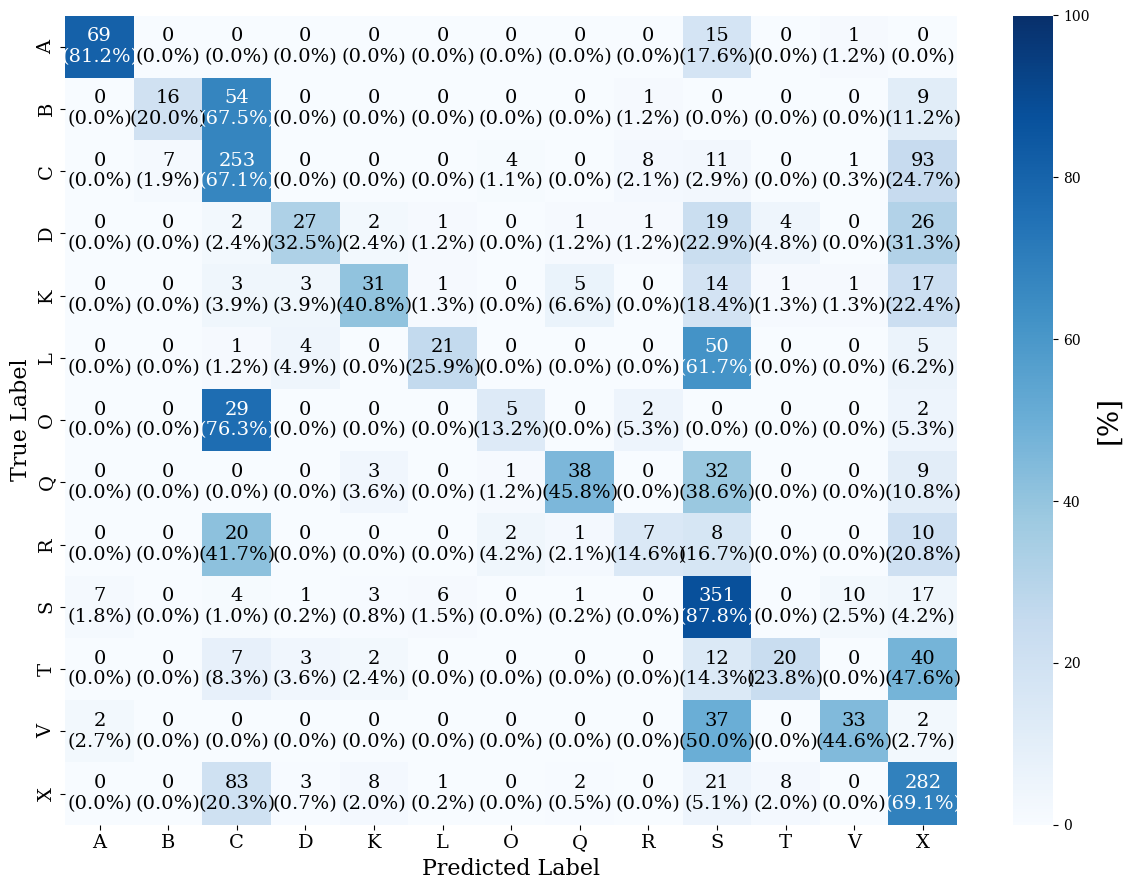

In [31]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from xgboost.callback import EarlyStopping
import xgboost as xgb
# import matplotlib.pyplot as plt # plot_confusion_matrix 사용 시 필요

# 전역 변수 또는 이 코드 이전에 정의되어야 할 변수들 (가정)
# path_save = "모델_저장_경로"
# class_names = [...] # LabelEncoder.classes_ 결과
# best_params = {...} # Optuna 튜닝 후 얻은 최적 파라미터 (예: best_params_xgb)
# train_data = xgb.DMatrix(X_train, label=y_train_encoded)
# test_data = xgb.DMatrix(X_test, label=y_test_encoded)
# y_test = y_test_encoded # y_test는 인코딩된 레이블이어야 합니다.
# plot_confusion_matrix 함수 정의 필요

os.makedirs(path_save, exist_ok=True)

df_cm_filename = os.path.join(path_save, f'confusion_matrix.csv')
report_csv_filename = os.path.join(path_save, f"classification_report.csv")
model_pkl_filename = os.path.join(path_save, f"xgboost_7DT.pkl")
confusion_matrix_png_filename = os.path.join(path_save, f'confusion_matrix.png')


if not os.path.exists(df_cm_filename) or \
   not os.path.exists(report_csv_filename) or \
   not os.path.exists(model_pkl_filename) or \
   not os.path.exists(confusion_matrix_png_filename):
    
    print(f"Start Training")
    
    current_best_params = best_params.copy()
    num_boost_round_final = current_best_params.pop('n_estimators', 2000) 

    # --- 핵심 수정 부분 ---
    # eval_metric과 objective, num_class를 명확히 설정
    current_best_params['eval_metric'] = 'mlogloss'
    current_best_params['objective'] = 'multi:softprob' # multi-class 분류임을 명확히
    current_best_params['num_class'] = len(class_names) # 클래스 개수 명확히
    current_best_params['disable_default_eval_metric'] = 1 # 기본 메트릭 비활성화

    early_stopping_callback = EarlyStopping(rounds=30, metric_name='mlogloss', data_name='validation')

    best_model = xgb.train(
        current_best_params, # n_estimators가 제거되고 eval_metric, objective 등이 설정된 파라미터 딕셔너리
        train_data,          # xgb.DMatrix 객체
        num_boost_round=num_boost_round_final,
        evals=[(test_data, 'validation')], # 검증 데이터셋 (xgb.DMatrix)
        callbacks=[early_stopping_callback], # 콜백 리스트 전달
        verbose_eval=False
    )
    # --- 수정 부분 끝 ---

    if hasattr(best_model, 'best_iteration') and best_model.best_iteration is not None:
        y_pred_proba = best_model.predict(test_data, iteration_range=(0, best_model.best_iteration))
    else:
        y_pred_proba = best_model.predict(test_data)
        
    y_pred_encoded = np.argmax(y_pred_proba, axis=1)

    joblib.dump(best_model, model_pkl_filename)

    print(f"Get Classification Report")
    #
    class_dict = {}
    for ii, class_name in enumerate(class_names):
        class_dict[f"{ii}"] = class_name

    y_pred_str = [class_dict[f"{ii}"] for ii in y_pred_encoded]

    # y_pred_str
    #
    report_dict = classification_report(y_test, y_pred_str, target_names=class_names, output_dict=True, zero_division=0)
    
    acc_value = report_dict.pop("accuracy")
    
    report_df = pd.DataFrame(report_dict).T
    
    report_df.loc["accuracy"] = [None, None, acc_value, report_df["support"].sum()]
    report_df.to_csv(report_csv_filename)

    print(f"Get Confusion Matrix")
    plot_confusion_matrix(y_test, y_pred_str, class_names)
    # plt.savefig(confusion_matrix_png_filename) # plt 임포트 및 함수 확인
    # plt.close()
    
    cm = confusion_matrix(y_test, y_pred_str)
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    df_cm.to_csv(df_cm_filename)
else:
    print(f"All result files ({df_cm_filename}, etc.) already exist. Skipping training and evaluation.")

# Results - 5-fold CV

In [32]:
from sklearn.model_selection import GroupKFold


In [33]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

gkf = GroupKFold(n_splits=5)
cv_macro_f1_scores = []
cv_per_class_f1_scores = []

print(f"Calculate 5-Fold Cross-Validation Values")

all_dmatrix = xgb.DMatrix(X, label=y_encoded)
class_count = len(class_names)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_encoded, groups=uids)):
    macro_f1_df_filename = os.path.join(path_save, f"cv_macro_f1_scores_{fold}.csv")
    per_class_f1_df_filename = os.path.join(path_save, f"cv_per_class_f1_scores_{fold}.csv")

    if (not os.path.exists(macro_f1_df_filename)) or (not os.path.exists(per_class_f1_df_filename)):
        # Fold별 파라미터 복사 (pop 등으로 손상되지 않게 반드시 copy!)
        fold_params = current_best_params.copy()
        num_boost_round_final = fold_params.pop('n_estimators', 2000)
        fold_params['eval_metric'] = 'mlogloss'
        fold_params['objective'] = 'multi:softprob'
        fold_params['num_class'] = class_count
        fold_params['disable_default_eval_metric'] = 1

        early_stopping_callback = EarlyStopping(
            rounds=30, metric_name='mlogloss', data_name='validation'
        )

        train_dmatrix = all_dmatrix.slice(train_idx)
        val_dmatrix = all_dmatrix.slice(val_idx)

        model_cv = xgb.train(
            fold_params,
            train_dmatrix,
            num_boost_round=num_boost_round_final,
            evals=[(val_dmatrix, 'validation')],
            callbacks=[early_stopping_callback],
            verbose_eval=False
        )

        # Predict with best_iteration
        if hasattr(model_cv, 'best_iteration') and model_cv.best_iteration is not None:
            y_pred_proba = model_cv.predict(val_dmatrix, iteration_range=(0, model_cv.best_iteration))
        else:
            y_pred_proba = model_cv.predict(val_dmatrix)

        y_pred_encoded = np.argmax(y_pred_proba, axis=1)
        y_val_encoded = val_dmatrix.get_label().astype(int)

        # Macro F1 (정수값 기반)
        macro_f1 = f1_score(y_val_encoded, y_pred_encoded, average='macro')
        cv_macro_f1_scores.append({'fold': fold, 'f1_macro': macro_f1})

        # Per-class F1 (정수값 기반)
        report = classification_report(
            y_val_encoded,
            y_pred_encoded,
            labels=np.arange(class_count),
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
        # 클래스별 F1-score만 추출
        per_class_f1 = {name: report[name]['f1-score'] for name in class_names}
        per_class_f1['fold'] = fold
        cv_per_class_f1_scores.append(per_class_f1)

        # 결과 저장
        pd.DataFrame(cv_macro_f1_scores).to_csv(macro_f1_df_filename, index=False)
        pd.DataFrame(cv_per_class_f1_scores).to_csv(per_class_f1_df_filename, index=False)

        print(f"[Fold {fold}] f1_macro = {macro_f1:.3f}")
    else:
        print(macro_f1_df_filename, "exists")
        print(per_class_f1_df_filename, "exists")

Calculate 5-Fold Cross-Validation Values
[Fold 0] f1_macro = 0.427
[Fold 1] f1_macro = 0.460
[Fold 2] f1_macro = 0.455
[Fold 3] f1_macro = 0.445
[Fold 4] f1_macro = 0.438


In [34]:
# # 설정
# class_labels = label_encoder.classes_
# gkf = GroupKFold(n_splits=5)

# cv_macro_f1_scores = []
# cv_per_class_f1_scores = []


# print(f"Calculate 5-Fold Cross-Validation Values")

# all_dmatrix = xgb.DMatrix(X, label=y_encoded)

# current_best_params = best_params.copy()
# num_boost_round_final = current_best_params.pop('n_estimators', 2000) 
# current_best_params['eval_metric'] = 'mlogloss'
# current_best_params['objective'] = 'multi:softprob' # multi-class 분류임을 명확히
# current_best_params['num_class'] = len(class_names) # 클래스 개수 명확히
# current_best_params['disable_default_eval_metric'] = 1 # 기본 메트릭 비활성화
# early_stopping_callback = EarlyStopping(rounds=30, metric_name='mlogloss', data_name='validation')


# # Perform Grouped K-Fold Cross-Validation
# for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_encoded, groups=uids)):

#     macro_f1_df_filename = os.path.join(path_save, f"cv_macro_f1_scores_{fold}.csv")
#     per_class_f1_df_filename = os.path.join(path_save, f"cv_per_class_f1_scores_{fold}.csv")

#     if (not os.path.exists(macro_f1_df_filename)) & ((not os.path.exists(per_class_f1_df_filename))):
#         # X, y_encoded 부분을 Pool 객체 슬라이싱으로 수정
#         train_dmatrix = all_dmatrix.slice(train_idx) # Pool 객체를 인덱싱하여 train_pool 생성
#         val_dmatrix = all_dmatrix.slice(val_idx)     # Pool 객체를 인덱싱하여 val_pool 생성

#         # early_stopping_callback = EarlyStopping(rounds=30, metric_name='mlogloss', data_name='validation')
#         model_cv = xgb.train(
#             current_best_params, # n_estimators가 제거되고 eval_metric, objective 등이 설정된 파라미터 딕셔너리
#             train_dmatrix,          # xgb.DMatrix 객체
#             num_boost_round=num_boost_round_final,
#             evals=[(val_dmatrix, 'validation')], # 검증 데이터셋 (xgb.DMatrix)
#             callbacks=[early_stopping_callback], # 콜백 리스트 전달
#             verbose_eval=False
#         )
#         # --- 수정 부분 끝 ---

#         if hasattr(model_cv, 'best_iteration') and model_cv.best_iteration is not None:
#             y_pred_proba = model_cv.predict(val_dmatrix, iteration_range=(0, model_cv.best_iteration))
#         else:
#             y_pred_proba = model_cv.predict(val_dmatrix)
            
#         y_pred_encoded = np.argmax(y_pred_proba, axis=1)

#         class_dict = {}
#         for ii, class_name in enumerate(class_names):
#             class_dict[f"{ii}"] = class_name

#         y_pred_str = [class_dict[f"{ii}"] for ii in y_pred_encoded]

#         # X_val_cv 대신 val_pool을 사용하여 예측
#         y_pred = model_cv.predict(val_dmatrix)

#         y_val_str = [class_dict[f"{ii:g}"] for ii in val_dmatrix.get_label()]

#         # === 1. Macro F1 저장 ===
#         # y_val_cv 대신 val_pool.get_label()을 사용하여 실제 레이블 가져오기
#         # macro_f1 = f1_score(val_dmatrix.get_label(), y_pred_str, average='macro')
#         macro_f1 = f1_score(y_val_str, y_pred_str, average='macro')
#         cv_macro_f1_scores.append({'fold': fold, 'f1_macro': macro_f1})

#         # === 2. Per-class F1 저장 ===
#         # y_val_cv 대신 val_pool.get_label()을 사용하여 실제 레이블 가져오기
#         report = classification_report(y_val_str, y_pred_str, output_dict=True, zero_division=0)
#         per_class_f1 = {str(label): report[str(label)]['f1-score'] for i, label in enumerate(class_labels)} # Ensure keys are strings for report
#         per_class_f1['fold'] = fold
#         cv_per_class_f1_scores.append(per_class_f1)

#         # === 3. 모델 저장 ===
#         model_path = os.path.join(path_save, f"model_fold{fold}.pkl")
#         joblib.dump(model_cv, model_path)

#         # === 4. 리포트 출력 ===
#         print(f"[Fold {fold}] f1_macro = {macro_f1:.3f}")

#         # === 5. 최종 결과 저장 ===
#         # 루프 바깥에서 한 번만 저장하는 것이 효율적일 수 있으나,
#         # 각 폴드마다 저장하려면 현재 위치도 괜찮습니다.
#         macro_f1_df = pd.DataFrame(cv_macro_f1_scores)
#         per_class_f1_df = pd.DataFrame(cv_per_class_f1_scores)

#         macro_f1_df.to_csv(macro_f1_df_filename, index=False)
#         per_class_f1_df.to_csv(per_class_f1_df_filename, index=False)
#     else:
#         print(macro_f1_df_filename, "exists")
#         print(per_class_f1_df_filename, "exists")